Time Series Forecasting: Johnson & Johnson and Amazon

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


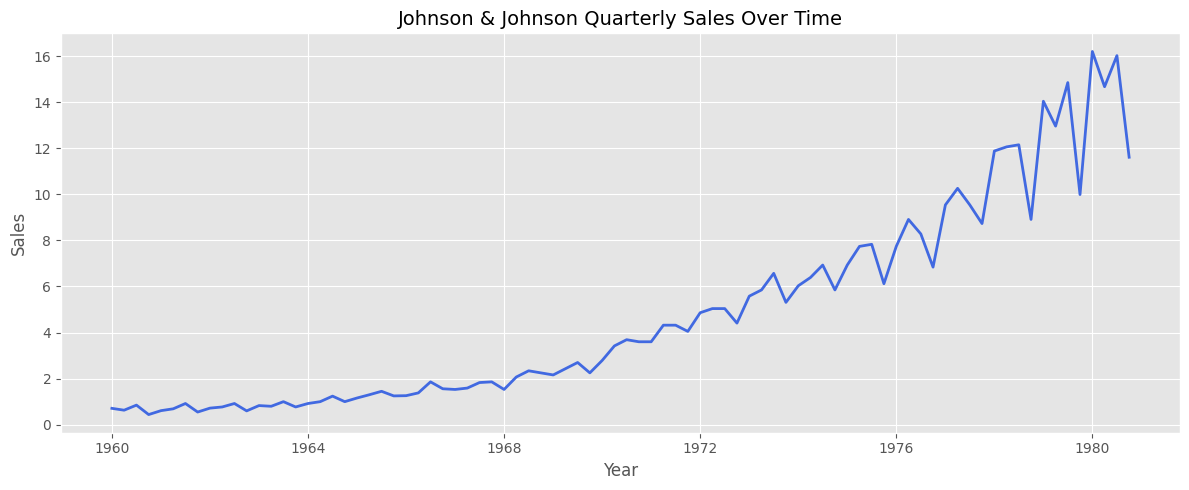

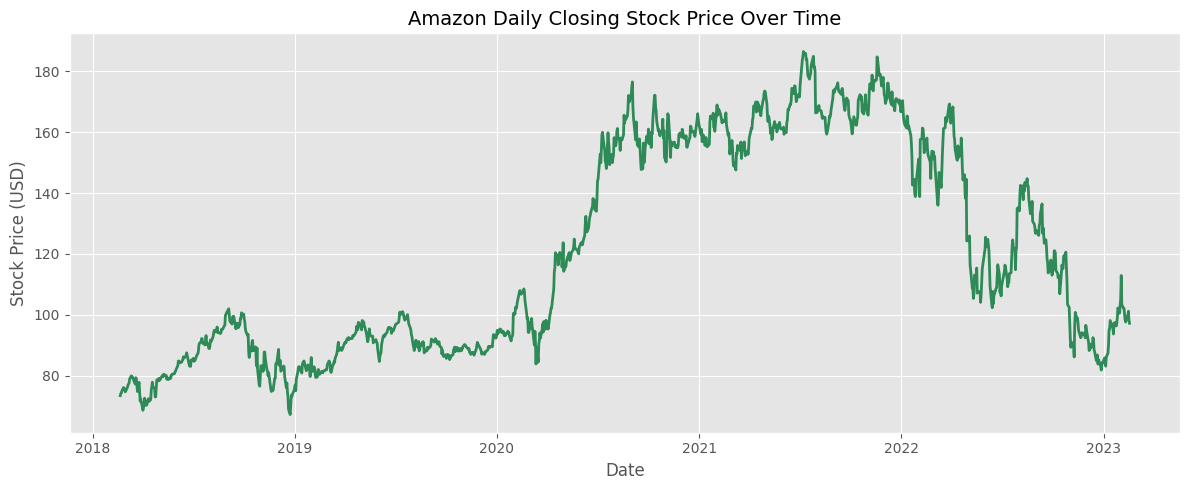

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Set a visual style for the plots
plt.style.use('ggplot')

# Load Johnson & Johnson sales dataset
jj = pd.read_csv("/content/drive/MyDrive/jj.csv")

# Load Amazon stock price dataset
amzn = pd.read_csv("/content/drive/MyDrive/AMZN.csv")

# Rename column for clarity
jj.columns = ['Date','Sales']
# Set 'Date' as the index
jj.set_index('Date', inplace=True)

# Convert index to datetime format for time series analysis
jj.index = pd.to_datetime(jj.index)

# Select relevant columns and format the date index for Amazon data
amzn = amzn[['Date', 'Close']]
amzn['Date'] = pd.to_datetime(amzn['Date'])
amzn.set_index('Date', inplace=True)

# Plot Johnson & Johnson sales time series
plt.figure(figsize=(12, 5))
plt.plot(jj, color='royalblue', linewidth=2)
plt.title('Johnson & Johnson Quarterly Sales Over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot Amazon closing stock price time series
plt.figure(figsize=(12, 5))
plt.plot(amzn, color='seagreen', linewidth=2)
plt.title('Amazon Daily Closing Stock Price Over Time', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()


ADF Test Result for: Johnson & Johnson Sales
ADF Statistic: 2.7420
p-value: 1.0000
=> Series is Non-Stationary
--------------------------------------------------
ADF Test Result for: Amazon Stock Price
ADF Statistic: -1.6578
p-value: 0.4530
=> Series is Non-Stationary
--------------------------------------------------
ADF Test Result for: JJ Sales (Differenced)
ADF Statistic: -0.4074
p-value: 0.9089
=> Series is Non-Stationary
--------------------------------------------------
ADF Test Result for: Amazon Close (Differenced)
ADF Statistic: -36.2508
p-value: 0.0000
=> Series is Stationary
--------------------------------------------------


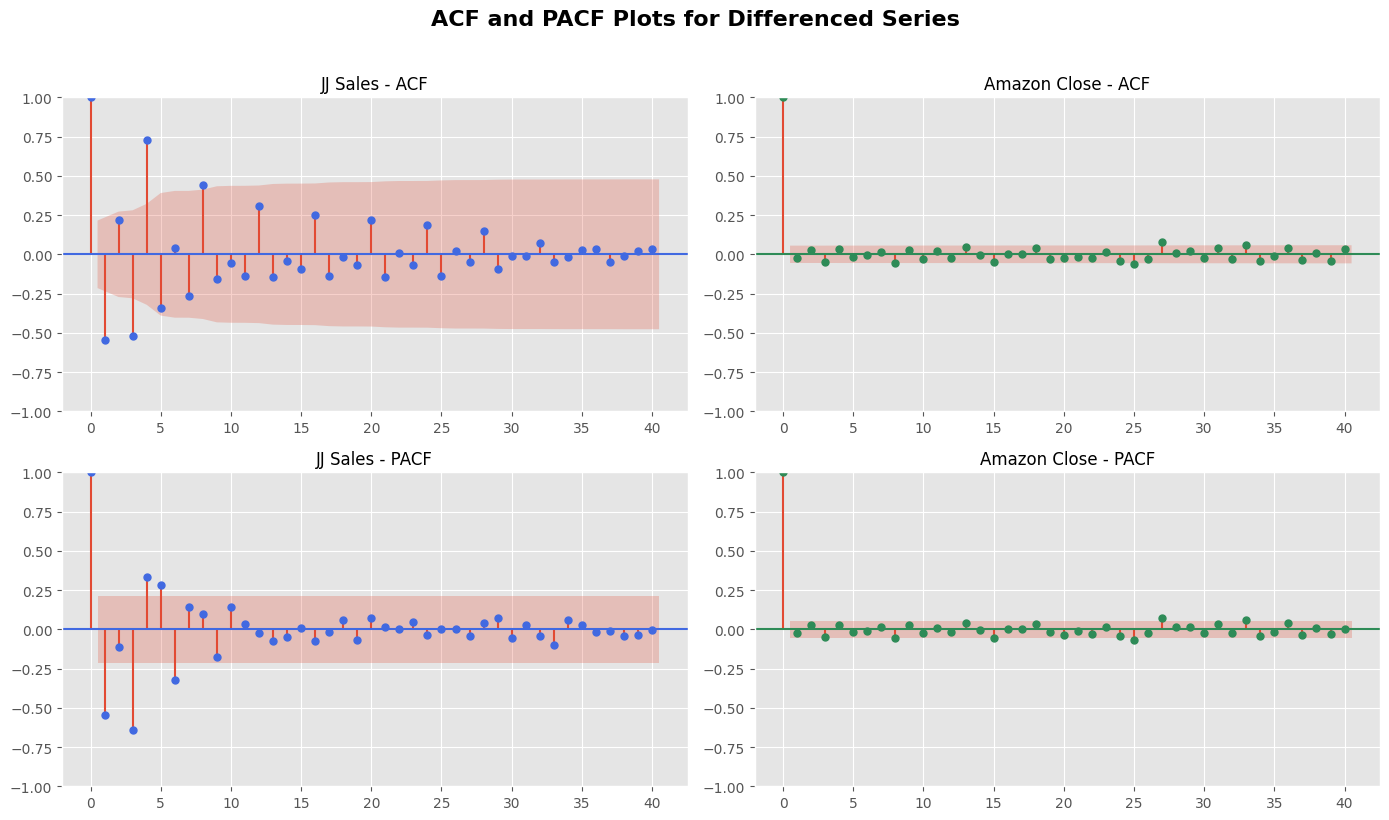

In [12]:
# Perform Augmented Dickey-Fuller (ADF) test for stationarity
def adf_test(series, title=''):
    print(f'ADF Test Result for: {title}')
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('=> Series is Stationary' if result[1] < 0.05 else '=> Series is Non-Stationary')
    print('-' * 50)

# Apply ADF test on original series
adf_test(jj['Sales'], 'Johnson & Johnson Sales')
adf_test(amzn['Close'], 'Amazon Stock Price')

# First-order differencing to achieve stationarity
jj_diff = jj['Sales'].diff().dropna()
amzn_diff = amzn['Close'].diff().dropna()

# Apply ADF test again after differencing
adf_test(jj_diff, 'JJ Sales (Differenced)')
adf_test(amzn_diff, 'Amazon Close (Differenced)')

# Import plotting tools for ACF and PACF
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for both series
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("ACF and PACF Plots for Differenced Series", fontsize=16, fontweight='bold', y=1.02)

# ACF and PACF for JJ
plot_acf(jj_diff, ax=ax[0, 0], lags=40, color='royalblue')
ax[0, 0].set_title("JJ Sales - ACF", fontsize=12)
ax[0, 0].grid(True)

plot_pacf(jj_diff, ax=ax[1, 0], lags=40, method='ywm', color='royalblue')
ax[1, 0].set_title("JJ Sales - PACF", fontsize=12)
ax[1, 0].grid(True)

# ACF and PACF for Amazon
plot_acf(amzn_diff, ax=ax[0, 1], lags=40, color='seagreen')
ax[0, 1].set_title("Amazon Close - ACF", fontsize=12)
ax[0, 1].grid(True)

plot_pacf(amzn_diff, ax=ax[1, 1], lags=40, method='ywm', color='seagreen')
ax[1, 1].set_title("Amazon Close - PACF", fontsize=12)
ax[1, 1].grid(True)

plt.tight_layout()
plt.show()


ARIMA (ARMA) Modelling and Forecast

                               SARIMAX Results                                
Dep. Variable:                  Sales   No. Observations:                   84
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -128.371
Date:                Sat, 12 Apr 2025   AIC                            262.742
Time:                        08:29:37   BIC                            269.998
Sample:                             0   HQIC                           265.657
                                 - 84                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.3277      0.090     -3.657      0.000      -0.503      -0.152
ma.L1         -0.4313      0.093     -4.662      0.000      -0.613      -0.250
sigma2         1.2819      0.164      7.814      0.0

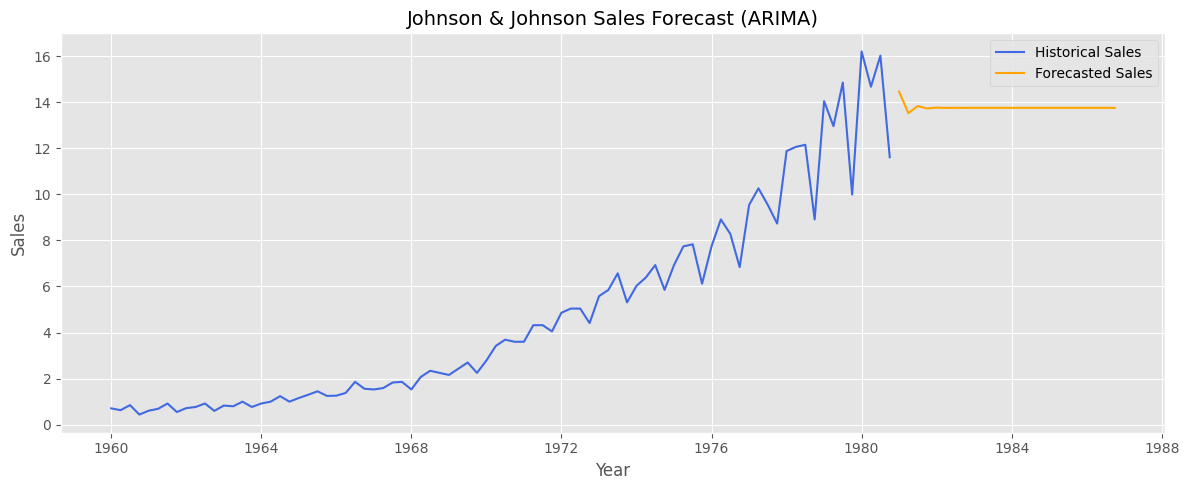

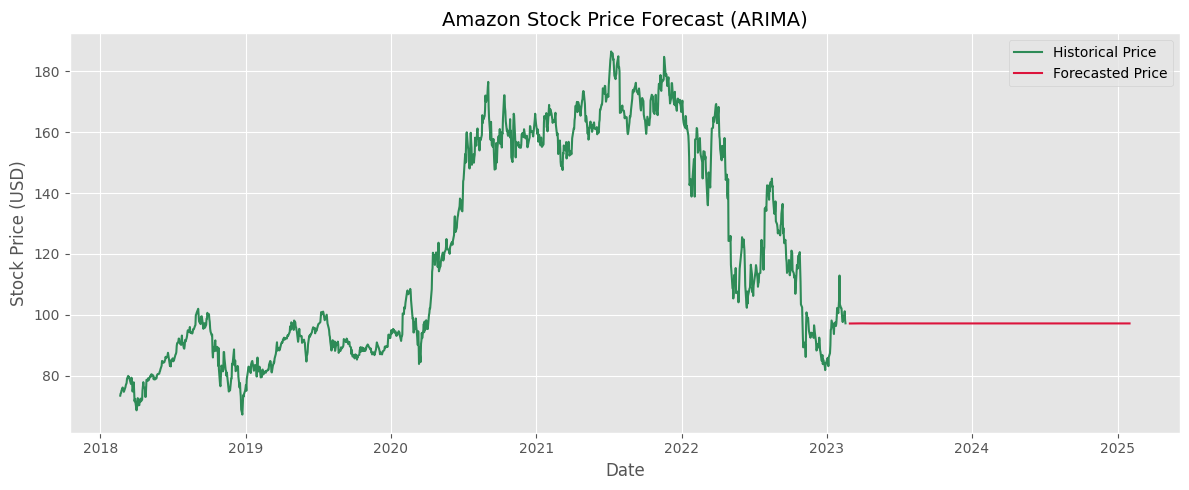

In [13]:
# ARIMA Modeling for Johnson & Johnson Sales
jj_model = ARIMA(jj['Sales'], order=(1, 1, 1))  # Parameters can be tuned using AIC/BIC
jj_fit = jj_model.fit()
print(jj_fit.summary())

# ARIMA Modeling for Amazon Stock Prices
amzn_model = ARIMA(amzn['Close'], order=(1, 1, 1))  # Parameters can be tuned using AIC/BIC
amzn_fit = amzn_model.fit()
print(amzn_fit.summary())

# Forecast next 24 periods (quarters for JJ, months for Amazon)
jj_forecast = jj_fit.forecast(steps=24)
amzn_forecast = amzn_fit.forecast(steps=24)

# Plotting JJ Forecast
plt.figure(figsize=(12, 5))
plt.plot(jj['Sales'], label='Historical Sales', color='royalblue')
plt.plot(pd.date_range(start=jj.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_forecast, label='Forecasted Sales', color='orange')
plt.title('Johnson & Johnson Sales Forecast (ARIMA)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plotting Amazon Forecast
plt.figure(figsize=(12, 5))
plt.plot(amzn['Close'], label='Historical Price', color='seagreen')
plt.plot(pd.date_range(start=amzn.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_forecast, label='Forecasted Price', color='crimson')
plt.title('Amazon Stock Price Forecast (ARIMA)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


 Neural Network Forecasting (LSTM / GRU)

In [14]:
# -----------------------------
# Function to create lagged features for RNN input
# -----------------------------
def prepare_data(series, n_lags=12):
    """
    Convert time series into sequences of lagged observations.
    :param series: Normalized time series as 1D array
    :param n_lags: Number of lag observations to use
    :return: X (input sequences), y (target values)
    """
    X, y = [], []
    for i in range(n_lags, len(series)):
        X.append(series[i - n_lags:i])
        y.append(series[i])
    return np.array(X), np.array(y)

# -----------------------------
# Normalize the series (Min-Max Scaling)
# -----------------------------
scaler_jj = MinMaxScaler()
jj_scaled = scaler_jj.fit_transform(jj['Sales'].values.reshape(-1, 1))

scaler_amzn = MinMaxScaler()
amzn_scaled = scaler_amzn.fit_transform(amzn['Close'].values.reshape(-1, 1))

# -----------------------------
# Create lagged sequences for RNN
# -----------------------------
X_jj, y_jj = prepare_data(jj_scaled, n_lags=12)
X_amzn, y_amzn = prepare_data(amzn_scaled, n_lags=12)

# -----------------------------
# Reshape input for RNN [samples, timesteps, features]
# -----------------------------
X_jj = X_jj.reshape((X_jj.shape[0], X_jj.shape[1], 1))
X_amzn = X_amzn.reshape((X_amzn.shape[0], X_amzn.shape[1], 1))

# Optional: Print shapes to verify
print(f'JJ RNN input shape: {X_jj.shape}, Target shape: {y_jj.shape}')
print(f'Amazon RNN input shape: {X_amzn.shape}, Target shape: {y_amzn.shape}')


JJ RNN input shape: (72, 12, 1), Target shape: (72, 1)
Amazon RNN input shape: (1247, 12, 1), Target shape: (1247, 1)


In [15]:
# -----------------------------
# Build RNN model (LSTM or GRU)
# -----------------------------
def build_model(input_shape, model_type='LSTM', units=64):
    """
    Builds and compiles a simple LSTM or GRU model.

    Parameters:
    - input_shape: Shape of input data (timesteps, features)
    - model_type: 'LSTM' or 'GRU'
    - units: Number of hidden units (default: 64)

    Returns:
    - Compiled Keras model
    """
    model = Sequential()
    if model_type.upper() == 'LSTM':
        model.add(LSTM(units, return_sequences=False, input_shape=input_shape))
    else:
        model.add(GRU(units, return_sequences=False, input_shape=input_shape))

    model.add(Dense(1))  # Output layer for regression
    model.compile(optimizer='adam', loss='mse')

    return model


In [16]:
# -----------------------------
# Train RNN model and forecast future steps
# -----------------------------
def train_forecast(X, y, scaler, model_type='LSTM', forecast_steps=24):
    """
    Trains an LSTM or GRU model on time series data and forecasts future values.

    Parameters:
    - X: Input sequence data (3D array)
    - y: Target values
    - scaler: Fitted MinMaxScaler used for inverse transforming predictions
    - model_type: Type of RNN ('LSTM' or 'GRU')
    - forecast_steps: Number of future time steps to predict

    Returns:
    - Inverse-transformed forecast values as a 1D NumPy array
    """
    # Build and train the model
    model = build_model((X.shape[1], 1), model_type=model_type)
    early_stop = EarlyStopping(patience=10, restore_best_weights=True)
    model.fit(X, y, epochs=100, batch_size=16, validation_split=0.2,
              callbacks=[early_stop], verbose=0)

    # Initialize prediction with the last available input sequence
    last_seq = X[-1]
    preds = []

    # Generate forecast iteratively (autoregressive style)
    for _ in range(forecast_steps):
        pred = model.predict(last_seq.reshape(1, -1, 1), verbose=0)[0]
        preds.append(pred)
        last_seq = np.append(last_seq[1:], pred).reshape(-1, 1)  # Slide the window

    # Inverse transform predictions to original scale
    preds = scaler.inverse_transform(np.array(preds).reshape(-1, 1)).flatten()
    return preds


In [17]:
# -----------------------------
# Run RNN Forecasts for Johnson & Johnson and Amazon
# -----------------------------

# ---- Johnson & Johnson Sales Forecast ----
print("Training and forecasting for Johnson & Johnson (LSTM)...")
jj_lstm_forecast = train_forecast(X_jj, y_jj, scaler_jj, model_type='LSTM')

print("Training and forecasting for Johnson & Johnson (GRU)...")
jj_gru_forecast = train_forecast(X_jj, y_jj, scaler_jj, model_type='GRU')

# ---- Amazon Stock Price Forecast ----
print("Training and forecasting for Amazon (LSTM)...")
amzn_lstm_forecast = train_forecast(X_amzn, y_amzn, scaler_amzn, model_type='LSTM')

print("Training and forecasting for Amazon (GRU)...")
amzn_gru_forecast = train_forecast(X_amzn, y_amzn, scaler_amzn, model_type='GRU')


Training and forecasting for Johnson & Johnson (LSTM)...
Training and forecasting for Johnson & Johnson (GRU)...
Training and forecasting for Amazon (LSTM)...
Training and forecasting for Amazon (GRU)...


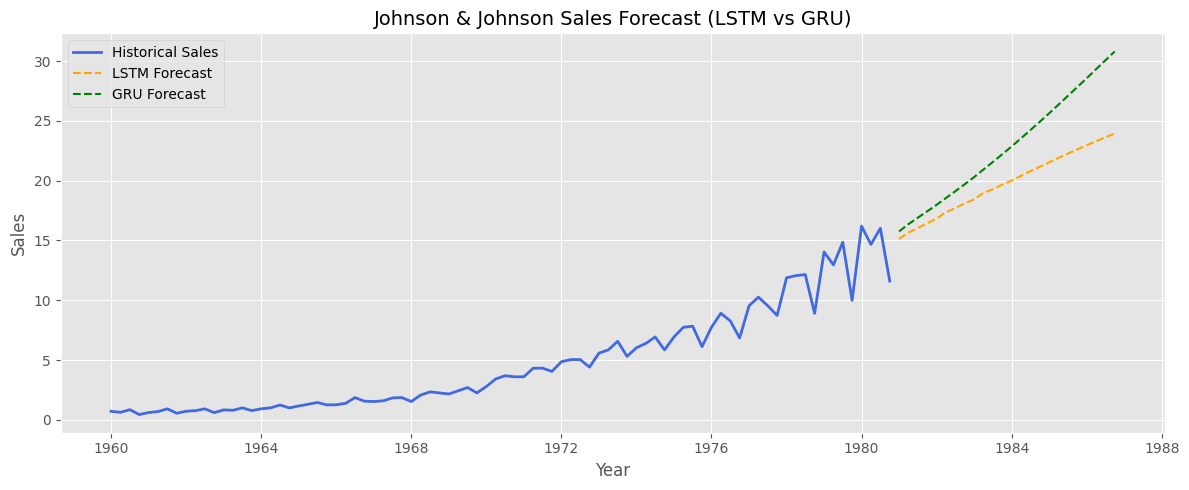

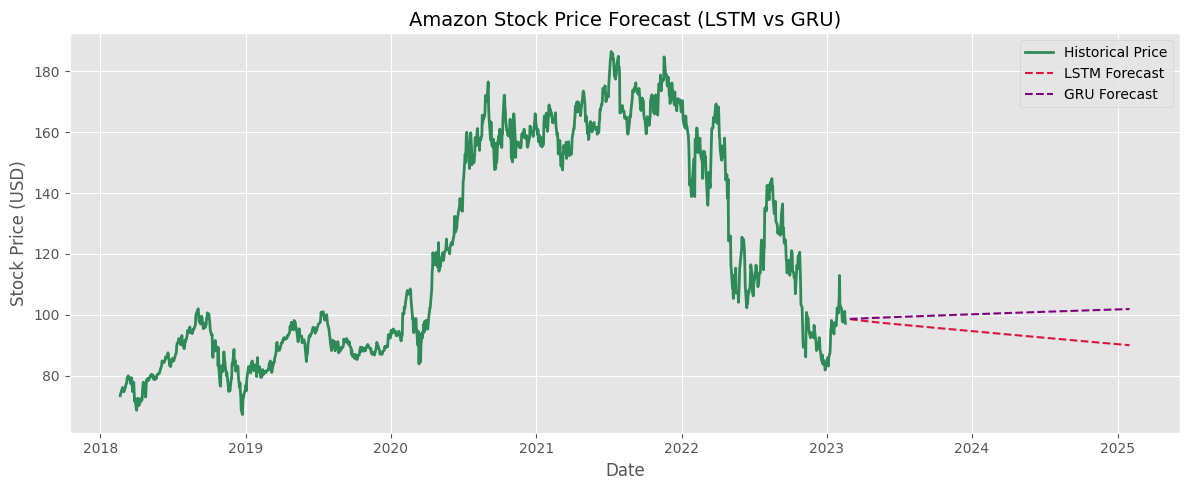

In [18]:
# -----------------------------
# Plot RNN Forecasts: LSTM vs GRU
# -----------------------------

# Johnson & Johnson Sales Forecast Plot
plt.figure(figsize=(12, 5))
plt.plot(jj['Sales'], label='Historical Sales', color='royalblue', linewidth=2)
plt.plot(pd.date_range(jj.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_lstm_forecast, label='LSTM Forecast', color='orange', linestyle='--')
plt.plot(pd.date_range(jj.index[-1] + pd.offsets.QuarterEnd(), periods=24, freq='Q'),
         jj_gru_forecast, label='GRU Forecast', color='green', linestyle='--')
plt.title('Johnson & Johnson Sales Forecast (LSTM vs GRU)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Sales')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Amazon Stock Price Forecast Plot
plt.figure(figsize=(12, 5))
plt.plot(amzn['Close'], label='Historical Price', color='seagreen', linewidth=2)
plt.plot(pd.date_range(amzn.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_lstm_forecast, label='LSTM Forecast', color='crimson', linestyle='--')
plt.plot(pd.date_range(amzn.index[-1] + pd.offsets.MonthEnd(), periods=24, freq='M'),
         amzn_gru_forecast, label='GRU Forecast', color='purple', linestyle='--')
plt.title('Amazon Stock Price Forecast (LSTM vs GRU)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Evaluation Metrics

In [19]:
# -----------------------------
# Evaluation Function
# -----------------------------
def evaluate(true, pred, model_name="Model"):
    """
    Evaluate model predictions using MSE and MAE.

    Parameters:
    - true: Actual values (1D array or Series)
    - pred: Predicted values (1D array)
    - model_name: Name of the model for display
    """
    mse = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    # rmse = np.sqrt(mse)  # Uncomment if RMSE needed
    print(f"{model_name:<15} | MSE: {mse:.4f} | MAE: {mae:.4f}")
    # print(f"{model_name:<15} | RMSE: {rmse:.4f} | MAE: {mae:.4f}")  # Optional RMSE output

# -----------------------------
# Prepare actual last 24 values
# -----------------------------
jj_true = jj['Sales'][-24:]
amzn_true = amzn['Close'][-24:]

# -----------------------------
# Evaluation: Johnson & Johnson
# -----------------------------
print(" Johnson & Johnson Forecast Evaluation")
evaluate(jj_true, jj_forecast, "JJ ARIMA")
evaluate(jj_true, jj_lstm_forecast, "JJ LSTM")
evaluate(jj_true, jj_gru_forecast, "JJ GRU")

print("\n Amazon Forecast Evaluation")
# -----------------------------
# Evaluation: Amazon
# -----------------------------
evaluate(amzn_true, amzn_forecast, "Amazon ARIMA")
evaluate(amzn_true, amzn_lstm_forecast, "Amazon LSTM")
evaluate(amzn_true, amzn_gru_forecast, "Amazon GRU")


 Johnson & Johnson Forecast Evaluation
JJ ARIMA        | MSE: 19.1454 | MAE: 3.7852
JJ LSTM         | MSE: 86.7879 | MAE: 9.1777
JJ GRU          | MSE: 156.9374 | MAE: 12.2551

 Amazon Forecast Evaluation
Amazon ARIMA    | MSE: 22.2112 | MAE: 3.2645
Amazon LSTM     | MSE: 59.4811 | MAE: 6.4657
Amazon GRU      | MSE: 14.0936 | MAE: 2.8976
